Matplotlib is building the font cache; this may take a moment.


Overall share planning AI: 25.2


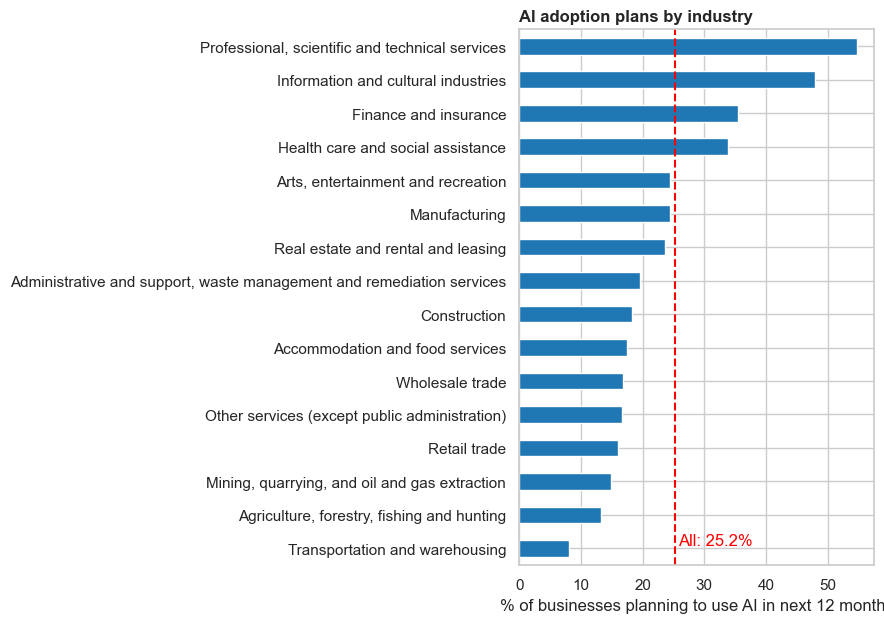

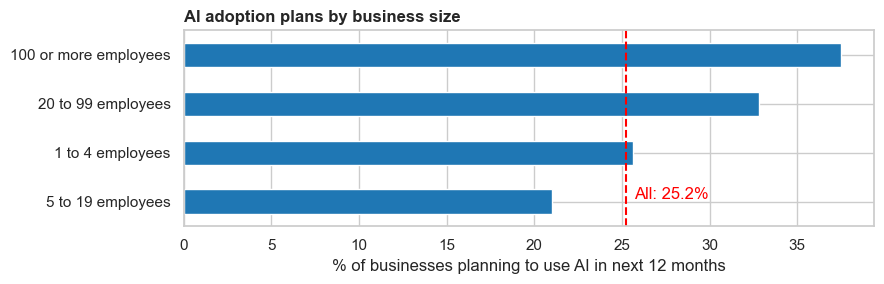

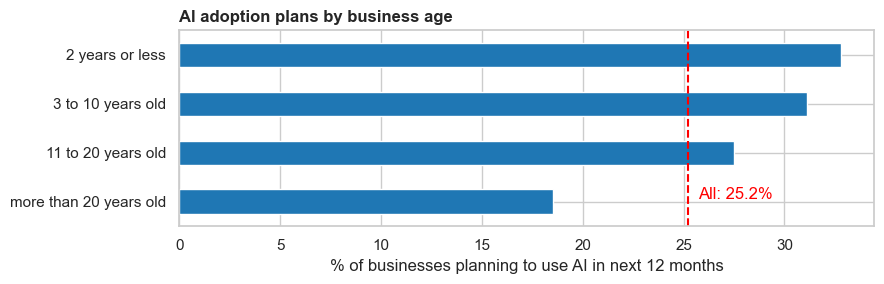

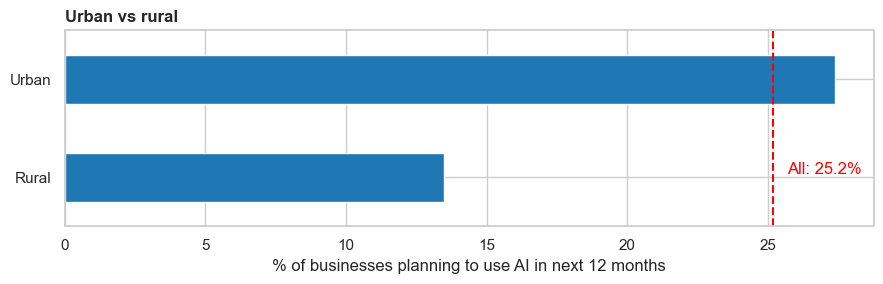

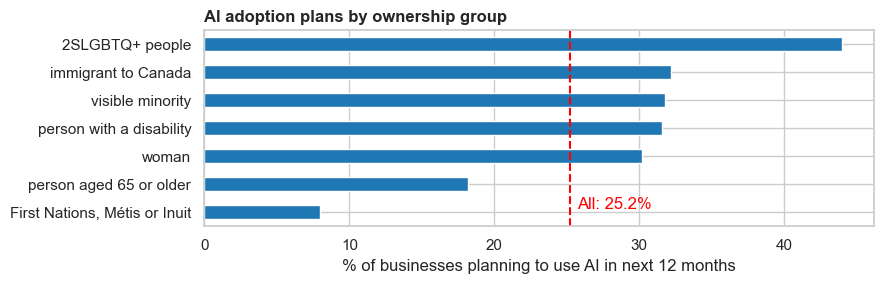

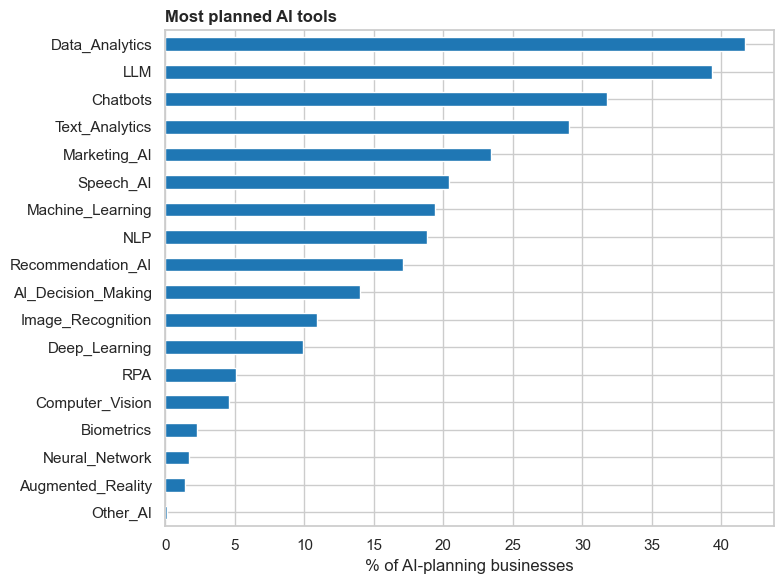

Quality grades for AI_Adoption:
AI_Adoption_grade
A    26
B    23
C     3
D     5
E     9
F     2
Name: count, dtype: int64


,Category,AI_Adoption,AI_Adoption_grade
0,"Professional, scientific and technical services",54.8,B
1,Information and cultural industries,48.0,B
2,Finance and insurance,35.5,B
3,Health care and social assistance,33.8,B
4,"Arts, entertainment and recreation",24.5,B


,Group,avg_adoption,spread
0,Visible minority ownership,35.1,100.0
1,Industry,24.1,46.8
2,International activity,44.4,44.4
3,Ownership,28.0,36.0
4,Size,29.2,16.5
5,Type,25.4,16.0
6,Age,27.5,14.3
7,Geography,20.4,13.9


381

In [1]:
import os, re, sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
os.makedirs("../docs", exist_ok=True)
os.makedirs("../sql", exist_ok=True)

# ---------- Load raw data and keep quality grades ----------
raw = pd.read_csv("../data/raw/3310120701-eng.csv", skiprows=9).iloc[2:70].reset_index(drop=True)
names = ["AI_Adoption","Machine_Learning","NLP","Chatbots","Speech_AI","Recommendation_AI","LLM",
         "Text_Analytics","Data_Analytics","Neural_Network","Augmented_Reality","AI_Decision_Making",
         "Deep_Learning","Image_Recognition","Computer_Vision","RPA","Biometrics","Marketing_AI",
         "Other_AI","No_AI","Unknown"]
raw.columns = ["Label"] + names

cells = raw[names].astype(str)
vals = cells.apply(lambda c: pd.to_numeric(c.str.extract(r"^([0-9.]+)")[0], errors="coerce"))
grades = cells.apply(lambda c: c.str.extract(r"([A-F])$")[0])

df = vals.copy()
df.insert(0, "Label", raw["Label"].str.replace(r"\s+\d+$", "", regex=True))
df["AI_Adoption_grade"] = grades["AI_Adoption"]

starts = [("Business or organization size", "Size"),
          ("Business or organization type", "Type"),
          ("Age of business or organization, all", "Age"),
          ("Geography", "Geography"),
          ("Majority ownership, all", "Ownership"),
          ("Ownership by visible minority, all", "Visible minority ownership"),
          ("Business or organization activity", "International activity")]
group, groups = "Industry", []
for i, lab in enumerate(df["Label"]):
    if i == 0:
        groups.append("Overall")
        continue
    for prefix, g in starts:
        if lab.startswith(prefix):
            group = g
    groups.append(group)
df["Group"] = groups
df["Is_Total"] = df["Label"].str.contains(", all ", regex=False) | (df.index == 0)
df["Category"] = [l if g in ("Industry", "Overall") else l.split(", ", 1)[-1]
                  for l, g in zip(df["Label"], df["Group"])]

overall = df.loc[0, "AI_Adoption"]
print("Overall share planning AI:", overall)

# ---------- Chart helper ----------
def bar(group, title, fname):
    d = (df[(df.Group == group) & (~df.Is_Total)]
         .dropna(subset=["AI_Adoption"]).sort_values("AI_Adoption"))
    colors = ["#b0b0b0" if g in ("E", "F") else "#1f77b4" for g in d["AI_Adoption_grade"]]
    ax = d.plot.barh(x="Category", y="AI_Adoption", legend=False, color=colors,
                     figsize=(9, max(3, 0.4 * len(d))))
    ax.axvline(overall, color="red", ls="--")
    ax.text(overall + 0.5, 0, f"All: {overall}%", color="red", va="bottom")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("% of businesses planning to use AI in next 12 months")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(f"../docs/{fname}", dpi=200)
    plt.show()

# ---------- Charts ----------
bar("Industry", "AI adoption plans by industry", "01_industry.png")
bar("Size", "AI adoption plans by business size", "02_size.png")
bar("Age", "AI adoption plans by business age", "03_age.png")
bar("Geography", "Urban vs rural", "05_geography.png")
bar("Ownership", "AI adoption plans by ownership group", "06_ownership.png")

tools = names[1:19]
t = df.loc[0, tools].sort_values()
ax = t.plot.barh(figsize=(8, 6), color="#1f77b4")
ax.set_title("Most planned AI tools", loc="left", fontweight="bold")
ax.set_xlabel("% of AI-planning businesses")
plt.tight_layout()
plt.savefig("../docs/04_tools.png", dpi=200)
plt.show()

# ---------- Data quality ----------
print("Quality grades for AI_Adoption:")
print(df["AI_Adoption_grade"].value_counts().sort_index())

# ---------- SQL ----------
con = sqlite3.connect(":memory:")
df.drop(columns=["Label"]).to_sql("ai_adoption", con, index=False)

q1 = """SELECT Category, AI_Adoption, AI_Adoption_grade
FROM ai_adoption
WHERE "Group" = 'Industry' AND AI_Adoption IS NOT NULL
ORDER BY AI_Adoption DESC
LIMIT 5;"""
q2 = """SELECT "Group", ROUND(AVG(AI_Adoption), 1) AS avg_adoption,
       ROUND(MAX(AI_Adoption) - MIN(AI_Adoption), 1) AS spread
FROM ai_adoption
WHERE Is_Total = 0 AND AI_Adoption IS NOT NULL
GROUP BY "Group"
ORDER BY spread DESC;"""
for q in (q1, q2):
    display(pd.read_sql(q, con))
open("../sql/queries.sql", "w").write(q1 + "\n\n" + q2)
